In [12]:
import os
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import MultiComparison



In [13]:
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)



   # HLM Predictions in the Random Split

In [14]:
# We start with one concrete question:
# "Which method appeared best for HLM predictions in the Random split?"
#
# This can be changed to "Scaffold" or "Butina" later when we extend the notebook.
SPLIT_METHOD = "Random"
TARGET = "HLM"
METRIC = "mae"



In [15]:
# Random Forest summary
rf = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/rf_ecfp4/summary/rf_ecfp4_metrics_summary.csv"
)

# ChemProp summaries
cp_st_hlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_single/hlm/summary/chemprop_metrics_summary.csv"
)

cp_st_fm_hlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_single_foundation/hlm/summary/chemprop_metrics_summary.csv"
)

cp_mt = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_multi/hlm_mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt_fm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_multi_foundation/hlm_mlm/summary/chemprop_metrics_summary.csv"
)



In [16]:
# Combine all model summaries into one table
allm = pd.concat(
    [
        rf,
        cp_st_hlm,
        cp_st_fm_hlm,
        cp_mt,
        cp_mt_fm,
    ],
    ignore_index=True,
)

allm.head()


,target,n_train,n_val,rmse,mae,r2,kendall_tau,kendall_tau_pvalue,split_method,model_family,cv_iter,fold,comparison_label,n_test
0,HLM,2992.0,748.0,0.439619,0.319243,0.536772,0.560331,6.938845e-116,Random,RF_ECFP4,0,0,HLM_RF_ECFP4_Random,NaN
1,MLM,2992.0,748.0,0.450461,0.328891,0.620489,0.606119,8.668480e-136,Random,RF_ECFP4,0,0,MLM_RF_ECFP4_Random,NaN
2,HLM,2992.0,748.0,0.410393,0.301961,0.562610,0.573581,1.811860e-121,Random,RF_ECFP4,0,1,HLM_RF_ECFP4_Random,NaN
3,MLM,2992.0,748.0,0.453785,0.324509,0.568926,0.555247,2.739569e-114,Random,RF_ECFP4,0,1,MLM_RF_ECFP4_Random,NaN
4,HLM,2992.0,748.0,0.409632,0.299127,0.548734,0.572871,3.565795e-121,Random,RF_ECFP4,0,2,HLM_RF_ECFP4_Random,NaN


In [ ]:
# Keep only the split / target we want to answer first
print(f"Split: {SPLIT_METHOD}, Target: {TARGET}")
df = allm[(allm["split_method"] == SPLIT_METHOD) & (allm["target"] == TARGET)].copy()

# Each row is one fold from the 5x5 CV
# We will need this `cv_sample` column for statistical tests
df["cv_sample"] = df["cv_iter"].astype(str) + "_" + df["fold"].astype(str)

# Make method labels a bit cleaner for plotting / tables
method_name_map = {
    "RF_ECFP4": "RF",
    "ChemProp_ST": "ChemProp ST",
    "ChemProp_ST_FM": "ChemProp ST + FM",
    "ChemProp_MT": "ChemProp MT",
    "ChemProp_MT_FM": "ChemProp MT + FM",
}

df["method"] = df["model_family"].replace(method_name_map)

df.head()


Split: Random, Target: HLM


,target,n_train,n_val,rmse,mae,r2,kendall_tau,kendall_tau_pvalue,split_method,model_family,cv_iter,fold,comparison_label,n_test,cv_sample,method
0,HLM,2992.0,748.0,0.439619,0.319243,0.536772,0.560331,6.938845e-116,Random,RF_ECFP4,0,0,HLM_RF_ECFP4_Random,NaN,0_0,RF
2,HLM,2992.0,748.0,0.410393,0.301961,0.562610,0.573581,1.811860e-121,Random,RF_ECFP4,0,1,HLM_RF_ECFP4_Random,NaN,0_1,RF
4,HLM,2992.0,748.0,0.409632,0.299127,0.548734,0.572871,3.565795e-121,Random,RF_ECFP4,0,2,HLM_RF_ECFP4_Random,NaN,0_2,RF
6,HLM,2992.0,748.0,0.390360,0.285654,0.585850,0.598622,3.534089e-132,Random,RF_ECFP4,0,3,HLM_RF_ECFP4_Random,NaN,0_3,RF
8,HLM,2992.0,748.0,0.422346,0.315868,0.583477,0.589582,3.276912e-128,Random,RF_ECFP4,0,4,HLM_RF_ECFP4_Random,NaN,0_4,RF


In [22]:
pg.rm_anova(data=df, dv="mae", within="method", subject="cv_sample")

,Source,ddof1,ddof2,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher
0,method,4,96,420.510007,6.582972e-60,7.221667e-32,0.855482,0.51245,False,0.134141,9.841804e-07


In [8]:
# Quick check of what we have
df[["method", "cv_iter", "fold", METRIC]].head()



,method,cv_iter,fold,mae
0,RF,0,0,0.319243
2,RF,0,1,0.301961
4,RF,0,2,0.299127
6,RF,0,3,0.285654
8,RF,0,4,0.315868


In [9]:
# Summary table for MAE
summary = (
    df.groupby("method", as_index=False)[METRIC]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

summary



,index,method,count,mean,std,median,min,max
3,3,ChemProp ST + FM,25,0.297506,0.006240,0.296871,0.287114,0.310640
1,1,ChemProp MT + FM,25,0.300703,0.006473,0.299417,0.290690,0.318387
4,4,RF,25,0.305517,0.009580,0.305655,0.285654,0.322401
2,2,ChemProp ST,25,0.338485,0.010037,0.338376,0.308012,0.352348
0,0,ChemProp MT,25,0.348300,0.010770,0.350429,0.321443,0.366406


In [10]:
# The method with the lowest mean MAE is the one we treat as appearing best
best_method = summary.iloc[0]["method"]
best_mae = summary.iloc[0]["mean"]

print(f"Best method by mean {METRIC.upper()} for {TARGET} on {SPLIT_METHOD}:")
print(f"{best_method} (mean {METRIC} = {best_mae:.4f})")



Best method by mean MAE for HLM on Random:
ChemProp ST + FM (mean mae = 0.2975)


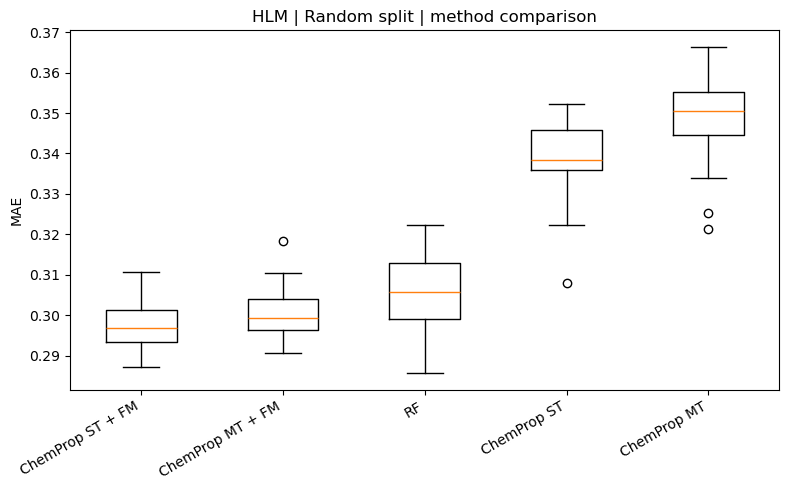

In [11]:
# Boxplot of fold-level MAE values
plot_order = summary["method"].tolist()

plot_data = [df.loc[df["method"] == method, METRIC].tolist() for method in plot_order]

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data, tick_labels=plot_order)
plt.ylabel("MAE")
plt.title(f"{TARGET} | {SPLIT_METHOD} split | method comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



In [12]:
# Tukey HSD on fold-level MAE values
# This is a simple first pass using the 25 fold-level values per method.
mc = MultiComparison(df[METRIC], df["method"])
tukey = mc.tukeyhsd()

print(tukey)



          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
     ChemProp MT ChemProp MT + FM  -0.0476    0.0 -0.0545 -0.0407   True
     ChemProp MT      ChemProp ST  -0.0098 0.0013 -0.0167 -0.0029   True
     ChemProp MT ChemProp ST + FM  -0.0508    0.0 -0.0577 -0.0439   True
     ChemProp MT               RF  -0.0428    0.0 -0.0497 -0.0359   True
ChemProp MT + FM      ChemProp ST   0.0378    0.0  0.0309  0.0447   True
ChemProp MT + FM ChemProp ST + FM  -0.0032 0.7035 -0.0101  0.0037  False
ChemProp MT + FM               RF   0.0048 0.3078 -0.0021  0.0117  False
     ChemProp ST ChemProp ST + FM   -0.041    0.0 -0.0479 -0.0341   True
     ChemProp ST               RF   -0.033    0.0 -0.0399 -0.0261   True
ChemProp ST + FM               RF    0.008 0.0145  0.0011  0.0149   True
---------------------------------------------------

In [13]:
# Turn Tukey results into a dataframe for easier viewing later
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)

tukey_df = tukey_df.sort_values(
    ["reject", "p-adj"],
    ascending=[False, True],
).reset_index(drop=True)

tukey_df



,group1,group2,meandiff,p-adj,lower,upper,reject
0,ChemProp MT,ChemProp MT + FM,-0.0476,0.0000,-0.0545,-0.0407,True
1,ChemProp MT,ChemProp ST + FM,-0.0508,0.0000,-0.0577,-0.0439,True
2,ChemProp MT,RF,-0.0428,0.0000,-0.0497,-0.0359,True
3,ChemProp MT + FM,ChemProp ST,0.0378,0.0000,0.0309,0.0447,True
4,ChemProp ST,ChemProp ST + FM,-0.0410,0.0000,-0.0479,-0.0341,True
5,ChemProp ST,RF,-0.0330,0.0000,-0.0399,-0.0261,True
6,ChemProp MT,ChemProp ST,-0.0098,0.0013,-0.0167,-0.0029,True
7,ChemProp ST + FM,RF,0.0080,0.0145,0.0011,0.0149,True
8,ChemProp MT + FM,RF,0.0048,0.3078,-0.0021,0.0117,False
9,ChemProp MT + FM,ChemProp ST + FM,-0.0032,0.7035,-0.0101,0.0037,False


In [14]:
# Pull out the MAE means again in a compact table for interpretation
mean_table = (
    df.groupby("method", as_index=False)[METRIC]
    .mean()
    .rename(columns={METRIC: "mean_mae"})
    .sort_values("mean_mae", ascending=True)
    .reset_index(drop=True)
)

mean_table



,method,mean_mae
0,ChemProp ST + FM,0.297506
1,ChemProp MT + FM,0.300703
2,RF,0.305517
3,ChemProp ST,0.338485
4,ChemProp MT,0.348300


Reference method for Tukey comparison:
ChemProp ST + FM (mean MAE = 0.2975)


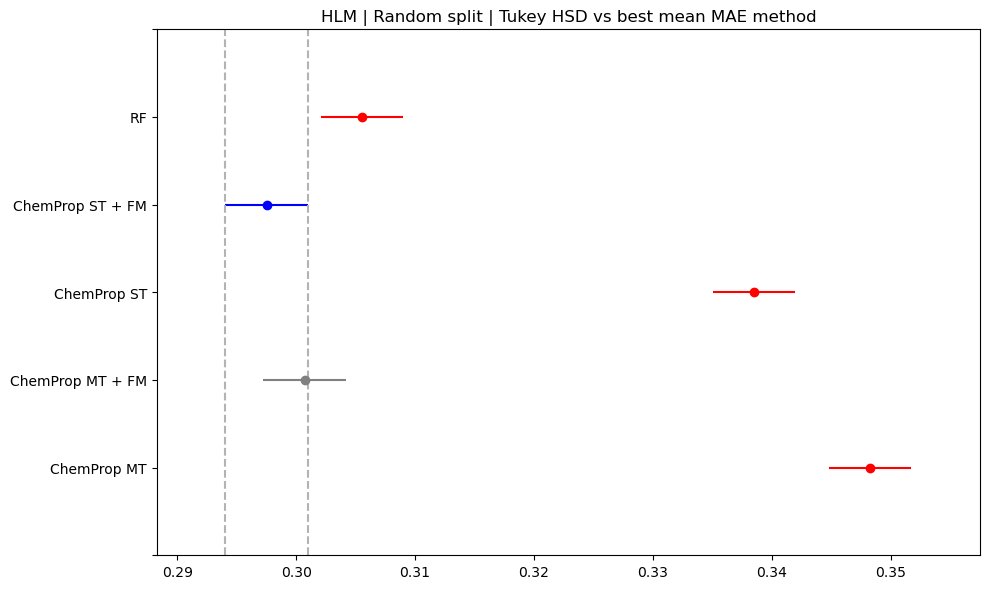

Saved figure to: ../figures/random_hlm_tukey_vs_best_mae.png


In [15]:
# We use the method with the lowest mean MAE as the reference method
best_method = mean_table.iloc[0]["method"]
best_mae = mean_table.iloc[0]["mean_mae"]

print("Reference method for Tukey comparison:")
print(f"{best_method} (mean MAE = {best_mae:.4f})")

# We follow the convention of Ash et al:
tukey.plot_simultaneous(comparison_name=best_method)
plt.title(f"{TARGET} | {SPLIT_METHOD} split | Tukey HSD vs best mean MAE method")
plt.tight_layout()

tukey_path = os.path.join(
    FIG_DIR,
    f"{SPLIT_METHOD.lower()}_{TARGET.lower()}_tukey_vs_best_{METRIC.lower()}.png",
)
plt.savefig(tukey_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {tukey_path}")



   # MLM Predictions in the Random Split

In [16]:
# We now ask the same question for MLM predictions in the Random split.
SPLIT_METHOD = "Random"
TARGET = "MLM"
METRIC = "mae"



In [17]:
# Random Forest summary
rf = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/rf_ecfp4/summary/rf_ecfp4_metrics_summary.csv"
)

# ChemProp summaries
cp_st_mlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_single/mlm/summary/chemprop_metrics_summary.csv"
)

cp_st_fm_mlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_single_foundation/mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_multi/hlm_mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt_fm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_multi_foundation/hlm_mlm/summary/chemprop_metrics_summary.csv"
)



In [18]:
# Combine all model summaries into one table
allm = pd.concat(
    [
        rf,
        cp_st_mlm,
        cp_st_fm_mlm,
        cp_mt,
        cp_mt_fm,
    ],
    ignore_index=True,
)



In [19]:
# Keep only the split / target we want to answer
df = allm[(allm["split_method"] == SPLIT_METHOD) & (allm["target"] == TARGET)].copy()

# Each row is one fold from the 5x5 CV
df["cv_sample"] = df["cv_iter"].astype(str) + "_" + df["fold"].astype(str)



In [20]:
# Make method labels a bit cleaner for plotting / tables
method_name_map = {
    "RF_ECFP4": "RF",
    "ChemProp_ST": "ChemProp ST",
    "ChemProp_ST_FM": "ChemProp ST + FM",
    "ChemProp_MT": "ChemProp MT",
    "ChemProp_MT_FM": "ChemProp MT + FM",
}

df["method"] = df["model_family"].replace(method_name_map)



In [21]:
# Quick check of what we have
df[["method", "cv_iter", "fold", METRIC]].head()



,method,cv_iter,fold,mae
1,RF,0,0,0.328891
3,RF,0,1,0.324509
5,RF,0,2,0.317784
7,RF,0,3,0.319348
9,RF,0,4,0.315021


In [22]:
# Summary table for MAE
summary = (
    df.groupby("method", as_index=False)[METRIC]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

summary



,index,method,count,mean,std,median,min,max
3,3,ChemProp ST + FM,25,0.320428,0.008278,0.322997,0.306066,0.344856
1,1,ChemProp MT + FM,25,0.320563,0.009088,0.319862,0.307662,0.337600
4,4,RF,25,0.322649,0.008980,0.322990,0.306648,0.340122
2,2,ChemProp ST,25,0.361348,0.008454,0.364145,0.344929,0.375159
0,0,ChemProp MT,25,0.369200,0.011745,0.369571,0.339520,0.393386


In [23]:
# The method with the lowest mean MAE is the one we treat as appearing best
best_method = summary.iloc[0]["method"]
best_mae = summary.iloc[0]["mean"]

print(f"Best method by mean {METRIC.upper()} for {TARGET} on {SPLIT_METHOD}:")
print(f"{best_method} (mean {METRIC} = {best_mae:.4f})")



Best method by mean MAE for MLM on Random:
ChemProp ST + FM (mean mae = 0.3204)


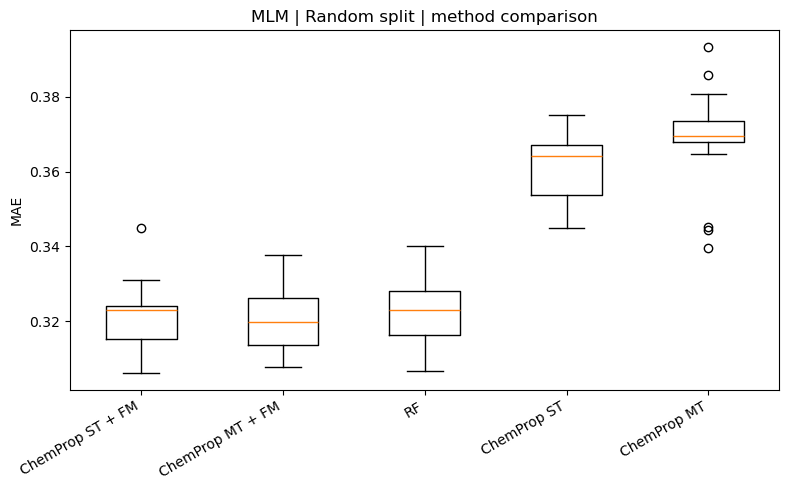

In [24]:
# Boxplot of fold-level MAE values
plot_order = summary["method"].tolist()

plot_data = [df.loc[df["method"] == method, METRIC].tolist() for method in plot_order]

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data, tick_labels=plot_order)
plt.ylabel("MAE")
plt.title(f"{TARGET} | {SPLIT_METHOD} split | method comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



In [25]:
# Tukey HSD on fold-level MAE values
# This is a simple first pass using the 25 fold-level values per method.
mc = MultiComparison(df[METRIC], df["method"])
tukey = mc.tukeyhsd()

print(tukey)



          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
     ChemProp MT ChemProp MT + FM  -0.0486    0.0  -0.056 -0.0413   True
     ChemProp MT      ChemProp ST  -0.0079 0.0303 -0.0152 -0.0005   True
     ChemProp MT ChemProp ST + FM  -0.0488    0.0 -0.0561 -0.0414   True
     ChemProp MT               RF  -0.0466    0.0 -0.0539 -0.0392   True
ChemProp MT + FM      ChemProp ST   0.0408    0.0  0.0334  0.0481   True
ChemProp MT + FM ChemProp ST + FM  -0.0001    1.0 -0.0075  0.0072  False
ChemProp MT + FM               RF   0.0021 0.9345 -0.0053  0.0094  False
     ChemProp ST ChemProp ST + FM  -0.0409    0.0 -0.0483 -0.0336   True
     ChemProp ST               RF  -0.0387    0.0 -0.0461 -0.0313   True
ChemProp ST + FM               RF   0.0022 0.9189 -0.0051  0.0096  False
---------------------------------------------------

In [26]:
# Turn Tukey results into a dataframe for easier viewing later
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)

tukey_df = tukey_df.sort_values(
    ["reject", "p-adj"],
    ascending=[False, True],
).reset_index(drop=True)

tukey_df



,group1,group2,meandiff,p-adj,lower,upper,reject
0,ChemProp MT,ChemProp MT + FM,-0.0486,0.0000,-0.0560,-0.0413,True
1,ChemProp MT,ChemProp ST + FM,-0.0488,0.0000,-0.0561,-0.0414,True
2,ChemProp MT,RF,-0.0466,0.0000,-0.0539,-0.0392,True
3,ChemProp MT + FM,ChemProp ST,0.0408,0.0000,0.0334,0.0481,True
4,ChemProp ST,ChemProp ST + FM,-0.0409,0.0000,-0.0483,-0.0336,True
5,ChemProp ST,RF,-0.0387,0.0000,-0.0461,-0.0313,True
6,ChemProp MT,ChemProp ST,-0.0079,0.0303,-0.0152,-0.0005,True
7,ChemProp ST + FM,RF,0.0022,0.9189,-0.0051,0.0096,False
8,ChemProp MT + FM,RF,0.0021,0.9345,-0.0053,0.0094,False
9,ChemProp MT + FM,ChemProp ST + FM,-0.0001,1.0000,-0.0075,0.0072,False


In [27]:
# Pull out the MAE means again in a compact table for interpretation
mean_table = (
    df.groupby("method", as_index=False)[METRIC]
    .mean()
    .rename(columns={METRIC: "mean_mae"})
    .sort_values("mean_mae", ascending=True)
    .reset_index(drop=True)
)

mean_table



,method,mean_mae
0,ChemProp ST + FM,0.320428
1,ChemProp MT + FM,0.320563
2,RF,0.322649
3,ChemProp ST,0.361348
4,ChemProp MT,0.369200


Reference method for Tukey comparison:
ChemProp ST + FM (mean MAE = 0.3204)


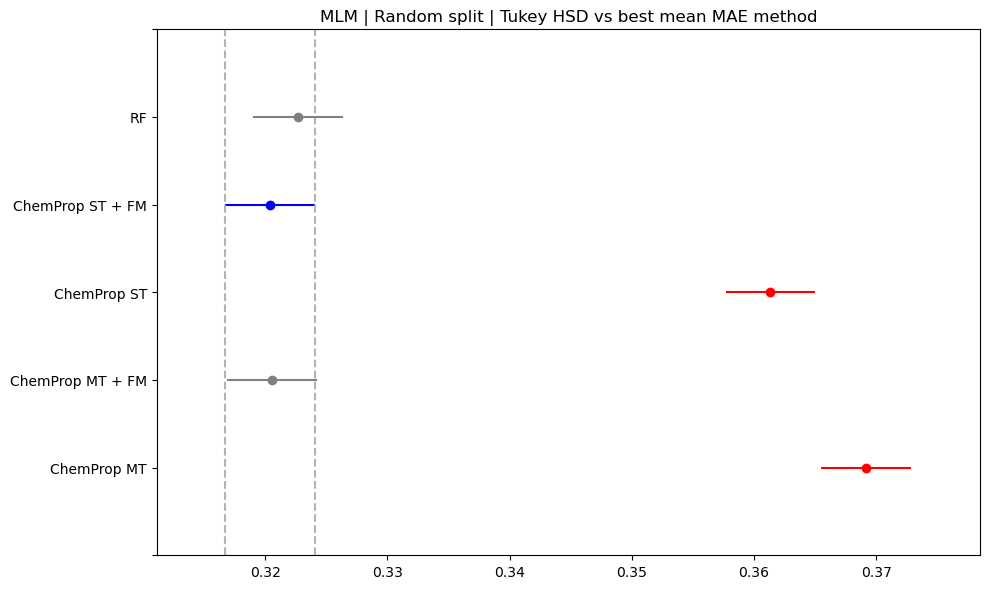

Saved figure to: ../figures/random_mlm_tukey_vs_best_mae.png


In [28]:
# We use the method with the lowest mean MAE as the reference method
best_method = mean_table.iloc[0]["method"]
best_mae = mean_table.iloc[0]["mean_mae"]

print("Reference method for Tukey comparison:")
print(f"{best_method} (mean MAE = {best_mae:.4f})")

# We follow the convention of Ash et al:
tukey.plot_simultaneous(comparison_name=best_method)
plt.title(f"{TARGET} | {SPLIT_METHOD} split | Tukey HSD vs best mean MAE method")
plt.tight_layout()

tukey_path = os.path.join(
    FIG_DIR,
    f"{SPLIT_METHOD.lower()}_{TARGET.lower()}_tukey_vs_best_{METRIC.lower()}.png",
)
plt.savefig(tukey_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {tukey_path}")


  # HLM Predictions in the Scaffold Split

In [29]:
# We now ask the same question for HLM predictions in the Scaffold split.
SPLIT_METHOD = "Scaffold"
TARGET = "HLM"
METRIC = "mae"



In [30]:
# Random Forest summary
rf = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/rf_ecfp4/summary/rf_ecfp4_metrics_summary.csv"
)

# ChemProp summaries
cp_st_hlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/chemprop_single/hlm/summary/chemprop_metrics_summary.csv"
)

cp_st_fm_hlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/chemprop_single_foundation/hlm/summary/chemprop_metrics_summary.csv"
)

cp_mt = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/chemprop_multi/hlm_mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt_fm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/chemprop_multi_foundation/hlm_mlm/summary/chemprop_metrics_summary.csv"
)



In [31]:
# Combine all model summaries into one table
allm = pd.concat(
    [
        rf,
        cp_st_hlm,
        cp_st_fm_hlm,
        cp_mt,
        cp_mt_fm,
    ],
    ignore_index=True,
)



In [32]:
# Keep only the split / target we want to answer
df = allm[(allm["split_method"] == SPLIT_METHOD) & (allm["target"] == TARGET)].copy()

# Each row is one fold from the 5x5 CV
df["cv_sample"] = df["cv_iter"].astype(str) + "_" + df["fold"].astype(str)



In [33]:
# Make method labels a bit cleaner for plotting / tables
method_name_map = {
    "RF_ECFP4": "RF",
    "ChemProp_ST": "ChemProp ST",
    "ChemProp_ST_FM": "ChemProp ST + FM",
    "ChemProp_MT": "ChemProp MT",
    "ChemProp_MT_FM": "ChemProp MT + FM",
}

df["method"] = df["model_family"].replace(method_name_map)



In [34]:
# Quick check of what we have
df[["method", "cv_iter", "fold", METRIC]].head()



,method,cv_iter,fold,mae
0,RF,0,0,0.330596
2,RF,0,1,0.329929
4,RF,0,2,0.335250
6,RF,0,3,0.334192
8,RF,0,4,0.364122


In [35]:
# Summary table for MAE
summary = (
    df.groupby("method", as_index=False)[METRIC]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

summary



,index,method,count,mean,std,median,min,max
3,3,ChemProp ST + FM,25,0.326112,0.016244,0.327061,0.290802,0.354220
1,1,ChemProp MT + FM,25,0.326245,0.013242,0.326665,0.298130,0.346211
4,4,RF,25,0.338601,0.014085,0.335250,0.319439,0.375926
2,2,ChemProp ST,25,0.358730,0.013798,0.357718,0.334664,0.385718
0,0,ChemProp MT,25,0.366516,0.015373,0.366870,0.342417,0.394117


In [36]:
# The method with the lowest mean MAE is the one we treat as appearing best
best_method = summary.iloc[0]["method"]
best_mae = summary.iloc[0]["mean"]

print(f"Best method by mean {METRIC.upper()} for {TARGET} on {SPLIT_METHOD}:")
print(f"{best_method} (mean {METRIC} = {best_mae:.4f})")



Best method by mean MAE for HLM on Scaffold:
ChemProp ST + FM (mean mae = 0.3261)


In [37]:
# Tukey HSD on fold-level MAE values
# This is a simple first pass using the 25 fold-level values per method.
mc = MultiComparison(df[METRIC], df["method"])
tukey = mc.tukeyhsd()

print(tukey)



          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
     ChemProp MT ChemProp MT + FM  -0.0403    0.0 -0.0517 -0.0288   True
     ChemProp MT      ChemProp ST  -0.0078   0.33 -0.0192  0.0036  False
     ChemProp MT ChemProp ST + FM  -0.0404    0.0 -0.0518  -0.029   True
     ChemProp MT               RF  -0.0279    0.0 -0.0393 -0.0165   True
ChemProp MT + FM      ChemProp ST   0.0325    0.0  0.0211  0.0439   True
ChemProp MT + FM ChemProp ST + FM  -0.0001    1.0 -0.0116  0.0113  False
ChemProp MT + FM               RF   0.0124 0.0271  0.0009  0.0238   True
     ChemProp ST ChemProp ST + FM  -0.0326    0.0  -0.044 -0.0212   True
     ChemProp ST               RF  -0.0201    0.0 -0.0316 -0.0087   True
ChemProp ST + FM               RF   0.0125 0.0248  0.0011  0.0239   True
---------------------------------------------------

In [38]:
# Turn Tukey results into a dataframe for easier viewing later
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)

tukey_df = tukey_df.sort_values(
    ["reject", "p-adj"],
    ascending=[False, True],
).reset_index(drop=True)

tukey_df



,group1,group2,meandiff,p-adj,lower,upper,reject
0,ChemProp MT,ChemProp MT + FM,-0.0403,0.0000,-0.0517,-0.0288,True
1,ChemProp MT,ChemProp ST + FM,-0.0404,0.0000,-0.0518,-0.0290,True
2,ChemProp MT,RF,-0.0279,0.0000,-0.0393,-0.0165,True
3,ChemProp MT + FM,ChemProp ST,0.0325,0.0000,0.0211,0.0439,True
4,ChemProp ST,ChemProp ST + FM,-0.0326,0.0000,-0.0440,-0.0212,True
5,ChemProp ST,RF,-0.0201,0.0000,-0.0316,-0.0087,True
6,ChemProp ST + FM,RF,0.0125,0.0248,0.0011,0.0239,True
7,ChemProp MT + FM,RF,0.0124,0.0271,0.0009,0.0238,True
8,ChemProp MT,ChemProp ST,-0.0078,0.3300,-0.0192,0.0036,False
9,ChemProp MT + FM,ChemProp ST + FM,-0.0001,1.0000,-0.0116,0.0113,False


In [39]:
# Pull out the MAE means again in a compact table for interpretation
mean_table = (
    df.groupby("method", as_index=False)[METRIC]
    .mean()
    .rename(columns={METRIC: "mean_mae"})
    .sort_values("mean_mae", ascending=True)
    .reset_index(drop=True)
)

mean_table



,method,mean_mae
0,ChemProp ST + FM,0.326112
1,ChemProp MT + FM,0.326245
2,RF,0.338601
3,ChemProp ST,0.358730
4,ChemProp MT,0.366516


Reference method for Tukey comparison:
ChemProp ST + FM (mean MAE = 0.3261)


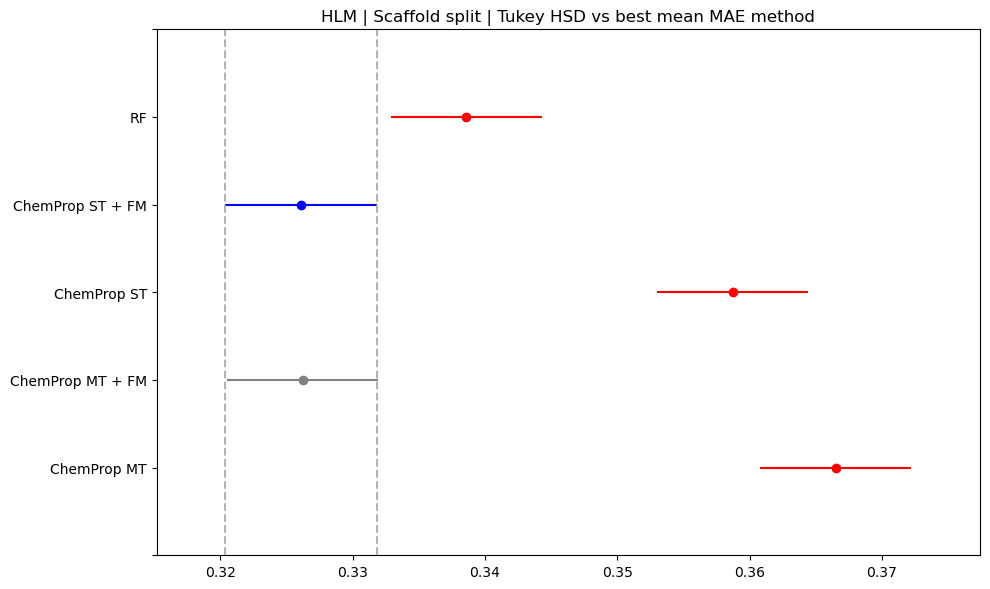

Saved figure to: ../figures/scaffold_hlm_tukey_vs_best_mae.png


In [40]:
# We use the method with the lowest mean MAE as the reference method
best_method = mean_table.iloc[0]["method"]
best_mae = mean_table.iloc[0]["mean_mae"]

print("Reference method for Tukey comparison:")
print(f"{best_method} (mean MAE = {best_mae:.4f})")

# We follow the convention of Ash et al:
tukey.plot_simultaneous(comparison_name=best_method)
plt.title(f"{TARGET} | {SPLIT_METHOD} split | Tukey HSD vs best mean MAE method")
plt.tight_layout()

tukey_path = os.path.join(
    FIG_DIR,
    f"{SPLIT_METHOD.lower()}_{TARGET.lower()}_tukey_vs_best_{METRIC.lower()}.png",
)
plt.savefig(tukey_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {tukey_path}")


  # MLM Predictions in the Scaffold Split

In [41]:
# We now ask the same question for MLM predictions in the Scaffold split.
SPLIT_METHOD = "Scaffold"
TARGET = "MLM"
METRIC = "mae"



In [42]:
# Random Forest summary
rf = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/rf_ecfp4/summary/rf_ecfp4_metrics_summary.csv"
)

# ChemProp summaries
cp_st_mlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/chemprop_single/mlm/summary/chemprop_metrics_summary.csv"
)

cp_st_fm_mlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/chemprop_single_foundation/mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/chemprop_multi/hlm_mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt_fm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/scaffold/chemprop_multi_foundation/hlm_mlm/summary/chemprop_metrics_summary.csv"
)



In [43]:
# Combine all model summaries into one table
allm = pd.concat(
    [
        rf,
        cp_st_mlm,
        cp_st_fm_mlm,
        cp_mt,
        cp_mt_fm,
    ],
    ignore_index=True,
)



In [44]:
# Keep only the split / target we want to answer
df = allm[(allm["split_method"] == SPLIT_METHOD) & (allm["target"] == TARGET)].copy()

# Each row is one fold from the 5x5 CV
df["cv_sample"] = df["cv_iter"].astype(str) + "_" + df["fold"].astype(str)



In [45]:
# Make method labels a bit cleaner for plotting / tables
method_name_map = {
    "RF_ECFP4": "RF",
    "ChemProp_ST": "ChemProp ST",
    "ChemProp_ST_FM": "ChemProp ST + FM",
    "ChemProp_MT": "ChemProp MT",
    "ChemProp_MT_FM": "ChemProp MT + FM",
}

df["method"] = df["model_family"].replace(method_name_map)



In [46]:
# Quick check of what we have
df[["method", "cv_iter", "fold", METRIC]].head()



,method,cv_iter,fold,mae
1,RF,0,0,0.371158
3,RF,0,1,0.343877
5,RF,0,2,0.358267
7,RF,0,3,0.370377
9,RF,0,4,0.342862


In [47]:
# Summary table for MAE
summary = (
    df.groupby("method", as_index=False)[METRIC]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

summary



,index,method,count,mean,std,median,min,max
1,1,ChemProp MT + FM,25,0.347204,0.017251,0.348652,0.320567,0.399951
3,3,ChemProp ST + FM,25,0.349762,0.015752,0.349568,0.319679,0.390680
4,4,RF,25,0.355811,0.015399,0.359390,0.328755,0.381918
2,2,ChemProp ST,25,0.377579,0.018667,0.375990,0.347542,0.419281
0,0,ChemProp MT,25,0.383785,0.017416,0.381787,0.356537,0.424865


In [48]:
# The method with the lowest mean MAE is the one we treat as appearing best
best_method = summary.iloc[0]["method"]
best_mae = summary.iloc[0]["mean"]

print(f"Best method by mean {METRIC.upper()} for {TARGET} on {SPLIT_METHOD}:")
print(f"{best_method} (mean {METRIC} = {best_mae:.4f})")



Best method by mean MAE for MLM on Scaffold:
ChemProp MT + FM (mean mae = 0.3472)


In [49]:
# Tukey HSD on fold-level MAE values
# This is a simple first pass using the 25 fold-level values per method.
mc = MultiComparison(df[METRIC], df["method"])
tukey = mc.tukeyhsd()

print(tukey)



          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
     ChemProp MT ChemProp MT + FM  -0.0366    0.0 -0.0499 -0.0233   True
     ChemProp MT      ChemProp ST  -0.0062 0.6946 -0.0195  0.0071  False
     ChemProp MT ChemProp ST + FM   -0.034    0.0 -0.0473 -0.0208   True
     ChemProp MT               RF   -0.028    0.0 -0.0412 -0.0147   True
ChemProp MT + FM      ChemProp ST   0.0304    0.0  0.0171  0.0436   True
ChemProp MT + FM ChemProp ST + FM   0.0026 0.9837 -0.0107  0.0158  False
ChemProp MT + FM               RF   0.0086 0.3804 -0.0047  0.0219  False
     ChemProp ST ChemProp ST + FM  -0.0278    0.0 -0.0411 -0.0145   True
     ChemProp ST               RF  -0.0218 0.0001  -0.035 -0.0085   True
ChemProp ST + FM               RF    0.006 0.7145 -0.0072  0.0193  False
---------------------------------------------------

In [50]:
# Turn Tukey results into a dataframe for easier viewing later
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)

tukey_df = tukey_df.sort_values(
    ["reject", "p-adj"],
    ascending=[False, True],
).reset_index(drop=True)

tukey_df



,group1,group2,meandiff,p-adj,lower,upper,reject
0,ChemProp MT,ChemProp MT + FM,-0.0366,0.0000,-0.0499,-0.0233,True
1,ChemProp MT,ChemProp ST + FM,-0.0340,0.0000,-0.0473,-0.0208,True
2,ChemProp MT,RF,-0.0280,0.0000,-0.0412,-0.0147,True
3,ChemProp MT + FM,ChemProp ST,0.0304,0.0000,0.0171,0.0436,True
4,ChemProp ST,ChemProp ST + FM,-0.0278,0.0000,-0.0411,-0.0145,True
5,ChemProp ST,RF,-0.0218,0.0001,-0.0350,-0.0085,True
6,ChemProp MT + FM,RF,0.0086,0.3804,-0.0047,0.0219,False
7,ChemProp MT,ChemProp ST,-0.0062,0.6946,-0.0195,0.0071,False
8,ChemProp ST + FM,RF,0.0060,0.7145,-0.0072,0.0193,False
9,ChemProp MT + FM,ChemProp ST + FM,0.0026,0.9837,-0.0107,0.0158,False


In [51]:
# Pull out the MAE means again in a compact table for interpretation
mean_table = (
    df.groupby("method", as_index=False)[METRIC]
    .mean()
    .rename(columns={METRIC: "mean_mae"})
    .sort_values("mean_mae", ascending=True)
    .reset_index(drop=True)
)

mean_table



,method,mean_mae
0,ChemProp MT + FM,0.347204
1,ChemProp ST + FM,0.349762
2,RF,0.355811
3,ChemProp ST,0.377579
4,ChemProp MT,0.383785


Reference method for Tukey comparison:
ChemProp MT + FM (mean MAE = 0.3472)


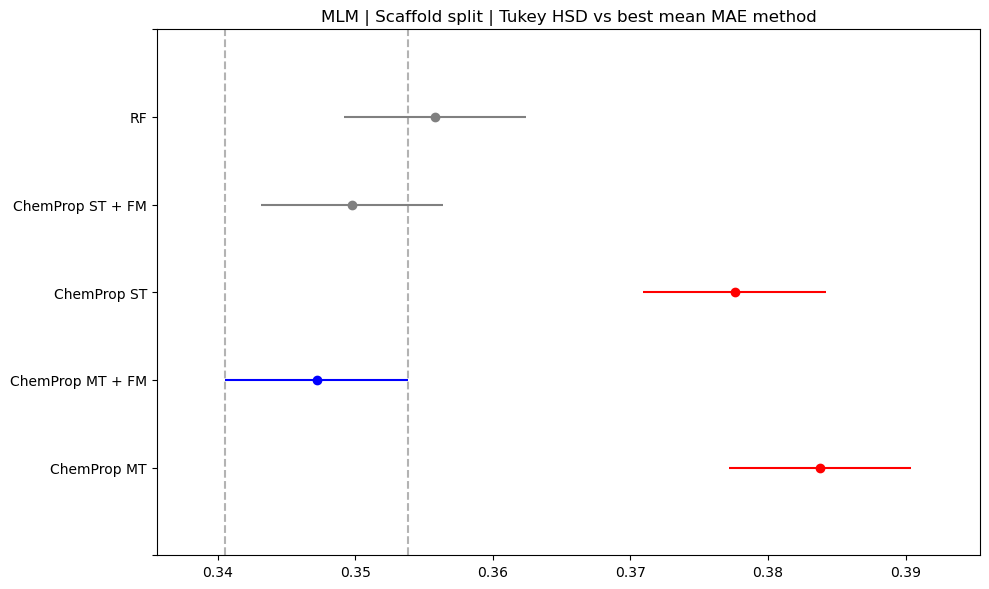

Saved figure to: ../figures/scaffold_mlm_tukey_vs_best_mae.png


In [52]:
# We use the method with the lowest mean MAE as the reference method
best_method = mean_table.iloc[0]["method"]
best_mae = mean_table.iloc[0]["mean_mae"]

print("Reference method for Tukey comparison:")
print(f"{best_method} (mean MAE = {best_mae:.4f})")

# We follow the convention of Ash et al:
tukey.plot_simultaneous(comparison_name=best_method)
plt.title(f"{TARGET} | {SPLIT_METHOD} split | Tukey HSD vs best mean MAE method")
plt.tight_layout()

tukey_path = os.path.join(
    FIG_DIR,
    f"{SPLIT_METHOD.lower()}_{TARGET.lower()}_tukey_vs_best_{METRIC.lower()}.png",
)
plt.savefig(tukey_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {tukey_path}")


 # HLM Predictions in the Butina Split

In [53]:
# We now ask the same question for HLM predictions in the Butina split.
SPLIT_METHOD = "Butina"
TARGET = "HLM"
METRIC = "mae"


In [54]:
# Random Forest summary
rf = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/rf_ecfp4/summary/rf_ecfp4_metrics_summary.csv"
)

# ChemProp summaries
cp_st_hlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/chemprop_single/hlm/summary/chemprop_metrics_summary.csv"
)

cp_st_fm_hlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/chemprop_single_foundation/hlm/summary/chemprop_metrics_summary.csv"
)

cp_mt = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/chemprop_multi/hlm_mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt_fm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/chemprop_multi_foundation/hlm_mlm/summary/chemprop_metrics_summary.csv"
)


In [55]:
# Combine all model summaries into one table
allm = pd.concat(
    [
        rf,
        cp_st_hlm,
        cp_st_fm_hlm,
        cp_mt,
        cp_mt_fm,
    ],
    ignore_index=True,
)


In [56]:
# Keep only the split / target we want to answer
df = allm[(allm["split_method"] == SPLIT_METHOD) & (allm["target"] == TARGET)].copy()

# Each row is one fold from the 5x5 CV
df["cv_sample"] = df["cv_iter"].astype(str) + "_" + df["fold"].astype(str)


In [57]:
# Make method labels a bit cleaner for plotting / tables
method_name_map = {
    "RF_ECFP4": "RF",
    "ChemProp_ST": "ChemProp ST",
    "ChemProp_ST_FM": "ChemProp ST + FM",
    "ChemProp_MT": "ChemProp MT",
    "ChemProp_MT_FM": "ChemProp MT + FM",
}

df["method"] = df["model_family"].replace(method_name_map)


In [58]:
# Quick check of what we have
df[["method", "cv_iter", "fold", METRIC]].head()


,method,cv_iter,fold,mae
0,RF,0,0,0.321627
2,RF,0,1,0.335770
4,RF,0,2,0.351995
6,RF,0,3,0.365058
8,RF,0,4,0.329712


In [59]:
# Summary table for MAE
summary = (
    df.groupby("method", as_index=False)[METRIC]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

summary


,index,method,count,mean,std,median,min,max
3,3,ChemProp ST + FM,25,0.324987,0.008856,0.325029,0.307427,0.340033
1,1,ChemProp MT + FM,25,0.327937,0.008683,0.327777,0.306793,0.344597
4,4,RF,25,0.339776,0.011670,0.337184,0.321627,0.367348
2,2,ChemProp ST,25,0.356565,0.010831,0.354941,0.342175,0.382677
0,0,ChemProp MT,25,0.363094,0.012178,0.365138,0.339528,0.383150


In [60]:
# The method with the lowest mean MAE is the one we treat as appearing best
best_method = summary.iloc[0]["method"]
best_mae = summary.iloc[0]["mean"]

print(f"Best method by mean {METRIC.upper()} for {TARGET} on {SPLIT_METHOD}:")
print(f"{best_method} (mean {METRIC} = {best_mae:.4f})")


Best method by mean MAE for HLM on Butina:
ChemProp ST + FM (mean mae = 0.3250)


In [61]:
# Tukey HSD on fold-level MAE values
# This is a simple first pass using the 25 fold-level values per method.
mc = MultiComparison(df[METRIC], df["method"])
tukey = mc.tukeyhsd()

print(tukey)


          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
     ChemProp MT ChemProp MT + FM  -0.0352    0.0 -0.0434 -0.0269   True
     ChemProp MT      ChemProp ST  -0.0065 0.1906 -0.0148  0.0017  False
     ChemProp MT ChemProp ST + FM  -0.0381    0.0 -0.0464 -0.0298   True
     ChemProp MT               RF  -0.0233    0.0 -0.0316 -0.0151   True
ChemProp MT + FM      ChemProp ST   0.0286    0.0  0.0204  0.0369   True
ChemProp MT + FM ChemProp ST + FM   -0.003 0.8596 -0.0112  0.0053  False
ChemProp MT + FM               RF   0.0118 0.0011  0.0036  0.0201   True
     ChemProp ST ChemProp ST + FM  -0.0316    0.0 -0.0398 -0.0233   True
     ChemProp ST               RF  -0.0168    0.0  -0.025 -0.0085   True
ChemProp ST + FM               RF   0.0148    0.0  0.0065   0.023   True
---------------------------------------------------

In [62]:
# Turn Tukey results into a dataframe for easier viewing later
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)

tukey_df = tukey_df.sort_values(
    ["reject", "p-adj"],
    ascending=[False, True],
).reset_index(drop=True)

tukey_df


,group1,group2,meandiff,p-adj,lower,upper,reject
0,ChemProp MT,ChemProp MT + FM,-0.0352,0.0000,-0.0434,-0.0269,True
1,ChemProp MT,ChemProp ST + FM,-0.0381,0.0000,-0.0464,-0.0298,True
2,ChemProp MT,RF,-0.0233,0.0000,-0.0316,-0.0151,True
3,ChemProp MT + FM,ChemProp ST,0.0286,0.0000,0.0204,0.0369,True
4,ChemProp ST,ChemProp ST + FM,-0.0316,0.0000,-0.0398,-0.0233,True
5,ChemProp ST,RF,-0.0168,0.0000,-0.0250,-0.0085,True
6,ChemProp ST + FM,RF,0.0148,0.0000,0.0065,0.0230,True
7,ChemProp MT + FM,RF,0.0118,0.0011,0.0036,0.0201,True
8,ChemProp MT,ChemProp ST,-0.0065,0.1906,-0.0148,0.0017,False
9,ChemProp MT + FM,ChemProp ST + FM,-0.0030,0.8596,-0.0112,0.0053,False


In [63]:
# Pull out the MAE means again in a compact table for interpretation
mean_table = (
    df.groupby("method", as_index=False)[METRIC]
    .mean()
    .rename(columns={METRIC: "mean_mae"})
    .sort_values("mean_mae", ascending=True)
    .reset_index(drop=True)
)

mean_table


,method,mean_mae
0,ChemProp ST + FM,0.324987
1,ChemProp MT + FM,0.327937
2,RF,0.339776
3,ChemProp ST,0.356565
4,ChemProp MT,0.363094


Reference method for Tukey comparison:
ChemProp ST + FM (mean MAE = 0.3250)


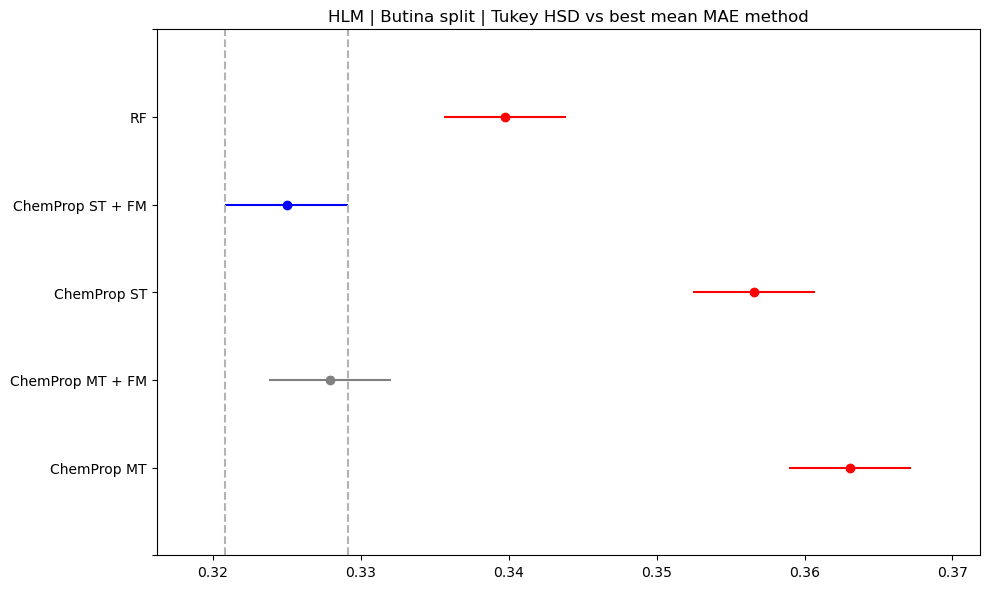

Saved figure to: ../figures/butina_hlm_tukey_vs_best_mae.png


In [64]:
# We use the method with the lowest mean MAE as the reference method
best_method = mean_table.iloc[0]["method"]
best_mae = mean_table.iloc[0]["mean_mae"]

print("Reference method for Tukey comparison:")
print(f"{best_method} (mean MAE = {best_mae:.4f})")

# We follow the convention of Ash et al:
tukey.plot_simultaneous(comparison_name=best_method)
plt.title(f"{TARGET} | {SPLIT_METHOD} split | Tukey HSD vs best mean MAE method")
plt.tight_layout()

tukey_path = os.path.join(
    FIG_DIR,
    f"{SPLIT_METHOD.lower()}_{TARGET.lower()}_tukey_vs_best_{METRIC.lower()}.png",
)
plt.savefig(tukey_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {tukey_path}")


 # MLM Predictions in the Butina Split

In [65]:
# We now ask the same question for MLM predictions in the Butina split.
SPLIT_METHOD = "Butina"
TARGET = "MLM"
METRIC = "mae"


In [66]:
# Random Forest summary
rf = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/rf_ecfp4/summary/rf_ecfp4_metrics_summary.csv"
)

# ChemProp summaries
cp_st_mlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/chemprop_single/mlm/summary/chemprop_metrics_summary.csv"
)

cp_st_fm_mlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/chemprop_single_foundation/mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/chemprop_multi/hlm_mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt_fm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/butina/chemprop_multi_foundation/hlm_mlm/summary/chemprop_metrics_summary.csv"
)


In [67]:
# Combine all model summaries into one table
allm = pd.concat(
    [
        rf,
        cp_st_mlm,
        cp_st_fm_mlm,
        cp_mt,
        cp_mt_fm,
    ],
    ignore_index=True,
)


In [68]:
# Keep only the split / target we want to answer
df = allm[(allm["split_method"] == SPLIT_METHOD) & (allm["target"] == TARGET)].copy()

# Each row is one fold from the 5x5 CV
df["cv_sample"] = df["cv_iter"].astype(str) + "_" + df["fold"].astype(str)


In [69]:
# Make method labels a bit cleaner for plotting / tables
method_name_map = {
    "RF_ECFP4": "RF",
    "ChemProp_ST": "ChemProp ST",
    "ChemProp_ST_FM": "ChemProp ST + FM",
    "ChemProp_MT": "ChemProp MT",
    "ChemProp_MT_FM": "ChemProp MT + FM",
}

df["method"] = df["model_family"].replace(method_name_map)


In [70]:
# Quick check of what we have
df[["method", "cv_iter", "fold", METRIC]].head()


,method,cv_iter,fold,mae
1,RF,0,0,0.340636
3,RF,0,1,0.361753
5,RF,0,2,0.354141
7,RF,0,3,0.383379
9,RF,0,4,0.343382


In [71]:
# Summary table for MAE
summary = (
    df.groupby("method", as_index=False)[METRIC]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

summary


,index,method,count,mean,std,median,min,max
1,1,ChemProp MT + FM,25,0.345424,0.016904,0.343924,0.318896,0.393267
3,3,ChemProp ST + FM,25,0.346778,0.015258,0.343674,0.321622,0.389760
4,4,RF,25,0.356328,0.016739,0.359388,0.329102,0.396887
2,2,ChemProp ST,25,0.378507,0.017651,0.375965,0.354451,0.429723
0,0,ChemProp MT,25,0.384676,0.019276,0.382147,0.351723,0.432606


In [72]:
# The method with the lowest mean MAE is the one we treat as appearing best
best_method = summary.iloc[0]["method"]
best_mae = summary.iloc[0]["mean"]

print(f"Best method by mean {METRIC.upper()} for {TARGET} on {SPLIT_METHOD}:")
print(f"{best_method} (mean {METRIC} = {best_mae:.4f})")


Best method by mean MAE for MLM on Butina:
ChemProp MT + FM (mean mae = 0.3454)


In [73]:
# Tukey HSD on fold-level MAE values
# This is a simple first pass using the 25 fold-level values per method.
mc = MultiComparison(df[METRIC], df["method"])
tukey = mc.tukeyhsd()

print(tukey)


          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
     ChemProp MT ChemProp MT + FM  -0.0393    0.0 -0.0527 -0.0258   True
     ChemProp MT      ChemProp ST  -0.0062 0.7119 -0.0197  0.0073  False
     ChemProp MT ChemProp ST + FM  -0.0379    0.0 -0.0514 -0.0244   True
     ChemProp MT               RF  -0.0283    0.0 -0.0418 -0.0149   True
ChemProp MT + FM      ChemProp ST   0.0331    0.0  0.0196  0.0466   True
ChemProp MT + FM ChemProp ST + FM   0.0014 0.9987 -0.0121  0.0148  False
ChemProp MT + FM               RF   0.0109 0.1725 -0.0026  0.0244  False
     ChemProp ST ChemProp ST + FM  -0.0317    0.0 -0.0452 -0.0182   True
     ChemProp ST               RF  -0.0222 0.0001 -0.0357 -0.0087   True
ChemProp ST + FM               RF   0.0095 0.2913 -0.0039   0.023  False
---------------------------------------------------

In [74]:
# Turn Tukey results into a dataframe for easier viewing later
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)

tukey_df = tukey_df.sort_values(
    ["reject", "p-adj"],
    ascending=[False, True],
).reset_index(drop=True)

tukey_df


,group1,group2,meandiff,p-adj,lower,upper,reject
0,ChemProp MT,ChemProp MT + FM,-0.0393,0.0000,-0.0527,-0.0258,True
1,ChemProp MT,ChemProp ST + FM,-0.0379,0.0000,-0.0514,-0.0244,True
2,ChemProp MT,RF,-0.0283,0.0000,-0.0418,-0.0149,True
3,ChemProp MT + FM,ChemProp ST,0.0331,0.0000,0.0196,0.0466,True
4,ChemProp ST,ChemProp ST + FM,-0.0317,0.0000,-0.0452,-0.0182,True
5,ChemProp ST,RF,-0.0222,0.0001,-0.0357,-0.0087,True
6,ChemProp MT + FM,RF,0.0109,0.1725,-0.0026,0.0244,False
7,ChemProp ST + FM,RF,0.0095,0.2913,-0.0039,0.0230,False
8,ChemProp MT,ChemProp ST,-0.0062,0.7119,-0.0197,0.0073,False
9,ChemProp MT + FM,ChemProp ST + FM,0.0014,0.9987,-0.0121,0.0148,False


In [75]:
# Pull out the MAE means again in a compact table for interpretation
mean_table = (
    df.groupby("method", as_index=False)[METRIC]
    .mean()
    .rename(columns={METRIC: "mean_mae"})
    .sort_values("mean_mae", ascending=True)
    .reset_index(drop=True)
)

mean_table


,method,mean_mae
0,ChemProp MT + FM,0.345424
1,ChemProp ST + FM,0.346778
2,RF,0.356328
3,ChemProp ST,0.378507
4,ChemProp MT,0.384676


Reference method for Tukey comparison:
ChemProp MT + FM (mean MAE = 0.3454)


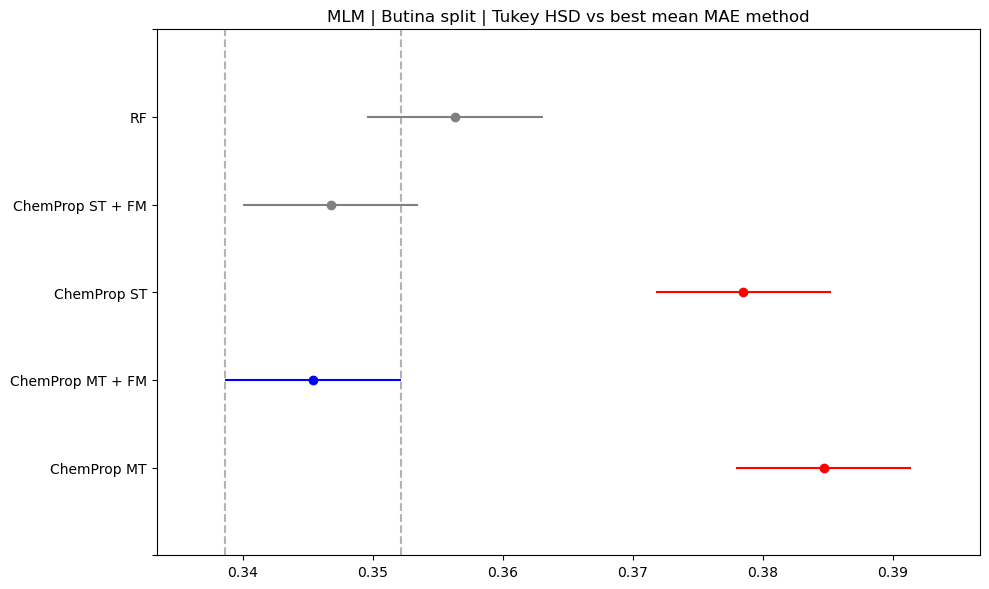

Saved figure to: ../figures/butina_mlm_tukey_vs_best_mae.png


In [76]:
# We use the method with the lowest mean MAE as the reference method
best_method = mean_table.iloc[0]["method"]
best_mae = mean_table.iloc[0]["mean_mae"]

print("Reference method for Tukey comparison:")
print(f"{best_method} (mean MAE = {best_mae:.4f})")

# We follow the convention of Ash et al:
tukey.plot_simultaneous(comparison_name=best_method)
plt.title(f"{TARGET} | {SPLIT_METHOD} split | Tukey HSD vs best mean MAE method")
plt.tight_layout()

tukey_path = os.path.join(
    FIG_DIR,
    f"{SPLIT_METHOD.lower()}_{TARGET.lower()}_tukey_vs_best_{METRIC.lower()}.png",
)
plt.savefig(tukey_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {tukey_path}")
